## Week 2 Day 2 - Orchestration

Our first Agentic Framework project!!

### Part 1: Email Setup

### Part 2: Orchestrating by code

### Part 3: Orchestrating by LLMs

- 3a: via Tools
- 3b: via Handoffs

## Part 1: Email Setup

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">IMPORTANT PLEASE READ - Sending Emails</h2>
            <span style="color:#ff7800;">We are going to write an agent that sends emails. The best way to do this is with an email provider
            like SendGrid or Resend. But this requires a fair amount of heavy-lifting: you need to send from a proper email host where you own the domain and you can prove it with DNS records. It's quite a hassle.<br/><br/>
            So we're going to do it the free & simple way: using SMTP server configuration to send direct from your email. It's an easy setup, but it's not as powerful (eg you can't receive emails). If you'd like to take this further, use SendGrid or Resend instead..<br/><br/>
            And actually the email send is optional. We're doing this to demonstrate an Agent sending emails. The important part is the Agent work, not the email sending. Feel free to swap out the function for a Pushover push if you'd prefer.
            </span>
        </td>
    </tr>
</table>

## Setting up to send emails from your SMTP server

### STEP 1: Determining your SMTP Server

Either google or ask ChatGPT / Claude for the SMTP server for your email. Here are some common ones. Some email providers might not have SMTP servers enabled (eg Microsoft 365 for work/school).

Google: smtp.gmail.com  
Outlook.com / Hotmail / Live: smtp-mail.outlook.com  
Microsoft 365: smtp.office365.com  
iCloud Mail: smtp.mail.me.com  

Add to your .env file:  

`EMAIL_SMTP_SERVER=xxxx`

### STEP 2: Obtain an app specific password

Google how to do this for your email provider. For gmail, you need to have 2-step verification on. Then visit this page:

https://myaccount.google.com/apppasswords

Give it any name; copy the password and add it to your .env file, removing the spaces that it adds. (It should be 16 characters, no spaces.)

`EMAIL_APP_PASSWORD=xxxx`

### STEP 3: Add in your email address:

`EMAIL_ADDRESS=xxx`

Remember to Save the .env file!

In [2]:
# 1. Setup local Arize Phoenix tracing
import os
from openinference.instrumentation.openai import OpenAIInstrumentor
from opentelemetry import trace as otel_trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import SimpleSpanProcessor
from opentelemetry.exporter.otlp.proto.http.trace_exporter import OTLPSpanExporter

tracer_provider = TracerProvider()
otel_trace.set_tracer_provider(tracer_provider)
span_exporter = OTLPSpanExporter(endpoint="http://localhost:6006/v1/traces")
span_processor = SimpleSpanProcessor(span_exporter)
tracer_provider.add_span_processor(span_processor)
OpenAIInstrumentor().instrument()

# 2. Standard imports
from dotenv import load_dotenv
import requests
from agents import Agent, Runner, trace, function_tool, ModelSettings, OpenAIChatCompletionsModel
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
from openai import AsyncOpenAI
import os
import asyncio
import smtplib
from email.message import EmailMessage
load_dotenv(override=True)

# Initialize AsyncOpenAI client pointing to Gemini endpoint
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
google_client = AsyncOpenAI(
    base_url=GEMINI_BASE_URL,
    api_key=os.getenv("GOOGLE_API_KEY") or os.getenv("GEMINI_API_KEY")
)

# Create the model mapping object for the Agents SDK using gemini-2.5-flash-lite
gemini_model = OpenAIChatCompletionsModel(
    model="gemini-3.1-flash-lite",
    openai_client=google_client
)


In [3]:
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")
EMAIL_SMTP_SERVER = os.getenv("EMAIL_SMTP_SERVER")
EMAIL_APP_PASSWORD = os.getenv("EMAIL_APP_PASSWORD")

if EMAIL_ADDRESS:
    print("Email address is set")
else:
    print("Email address is not set")

if EMAIL_SMTP_SERVER:
    print("SMTP server is set")
else:
    print("SMTP server is not set")

if EMAIL_APP_PASSWORD:
    print("App password is set")
else:
    print("App password is not set")

USE_EMAIL = EMAIL_ADDRESS and EMAIL_SMTP_SERVER and EMAIL_APP_PASSWORD

if USE_EMAIL:
    print("Email is set up and we will try using it")
else:
    print("Email is not set up; we will send push notifications instead")

Email address is set
SMTP server is set
App password is set
Email is set up and we will try using it


In [4]:
# Here we go

def send_email(subject, text_body, html_body):
    msg = EmailMessage()
    msg["From"] = EMAIL_ADDRESS
    msg["To"] = EMAIL_ADDRESS
    msg["Subject"] = subject
    msg.set_content(text_body)
    msg.add_alternative(html_body, subtype="html")

    with smtplib.SMTP(EMAIL_SMTP_SERVER, 587) as server:
        server.starttls()
        server.login(EMAIL_ADDRESS, EMAIL_APP_PASSWORD)
        server.send_message(msg)

In [5]:
send_email("Testing testing 123", "Fingers crossed..", "<html><body><strong>Fingers</strong> crossed..</body></html>")

### If this didn't work, then uncomment the below so that we don't use emails

In [ ]:
# USE_EMAIL = False

### Our fallback strategy - send a push

In [6]:
pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

if pushover_user:
    if pushover_user.startswith("u"):
        print("Pushover user found and looks good")
    else:
        print("Pushover user found but doesn't start with u")
else:
    print("Pushover user not found")

if pushover_token:
    if pushover_token.startswith("a"):
        print("Pushover token found and looks good")
    else:
        print("Pushover token found but doesn't start with a")
else:
    print("Pushover token not found")

Pushover user found and looks good
Pushover token found and looks good


In [7]:
def push(message):
    print(f"Push: {message}")
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)

In [7]:
def send_message(subject, text_body, html_body):
    if USE_EMAIL:
        send_email(subject, text_body, html_body)
    else:
        push(f"Subject: {subject}\n\n{text_body}")

### OK Now everything should work!

In [8]:
send_message("Big news", "Communications are a go!", "<html><body>Communications are a <strong>go!</strong></body></html>")

## Agent Orchestration

There are 2 models for Agent Orchestration; by code and by LLMs.

By code: more predictable and deterministic.

By LLMs: more powerful.

An excellent write-up is here:

https://openai.github.io/openai-agents-python/multi_agent/

We will start with by Code.

## Part 2: Orchestrating by Code

In [8]:
intro = """
You are a sales agent working for ComplAI, 
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI.
You write emails.
"""

instructions1 = intro + "Your email style is professional, serious, with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of a busy senior executive."

In [9]:
sales_agent1 = Agent(name="Professional Sales Agent", instructions=instructions1, model=gemini_model)
sales_agent2 = Agent(name="Humorous Sales Agent", instructions=instructions2, model=gemini_model)
sales_agent3 = Agent(name="Executive Sales Agent", instructions=instructions3, model=gemini_model)


In [11]:

result = Runner.run_streamed(sales_agent1, input="Write a cold sales email")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

Subject: Scaling your security posture / SOC2 audit readiness

Dear [Prospect Name],

As [Company Name] continues to scale, the friction between operational velocity and the rigorous demands of SOC2 compliance often becomes a primary bottleneck. Most organizations find that the manual overhead required to achieve and maintain compliance—gathering evidence, mapping controls, and preparing for external audits—diverts critical engineering talent away from product development.

At ComplAI, we have developed an AI-driven platform specifically engineered to accelerate the SOC2 certification process. Our solution automates the continuous collection of audit evidence and maps your infrastructure against security frameworks in real-time. By bridging the gap between automated monitoring and audit readiness, we enable our clients to achieve compliance mandates in a fraction of the traditional timeline.

We have supported organizations with similar operational profiles to yours in streamlining the

OPENAI_API_KEY is not set, skipping trace export


In [10]:
message = "Write a cold sales email"

with trace("Parallel cold emails"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )

outputs = [result.final_output for result in results]

for output in outputs:
    print(output + "\n\n")


Subject: Operationalizing your SOC2 audit readiness

Dear [Prospect Name],

For many organizations, the path to SOC2 compliance is perceived as a significant drain on internal resources—an exercise characterized by months of manual documentation, fragmented evidence collection, and avoidable audit fatigue.

At ComplAI, we have reimagined this process. By leveraging proprietary AI to automate the mapping of your technical controls against SOC2 standards, we provide a streamlined, continuous approach to audit readiness. Our platform allows security and engineering teams to shift their focus from manual evidence gathering to the strategic architecture of their security posture.

We have recently partnered with organizations similar to [Prospect Company] to accelerate their audit timelines by over 50%, while providing the rigorous documentation required by top-tier auditors.

I would appreciate the opportunity to learn more about [Prospect Company]’s current compliance roadmap and discuss 

OPENAI_API_KEY is not set, skipping trace export


In [11]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Do not give an explanation; reply with the selected email only.
"""

sales_picker = Agent(name="Sales_picker", instructions=decision, model=gemini_model)


In [12]:
message = "Write a cold sales email"

with trace("Sales selection workflow"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    best = await Runner.run(sales_picker, emails)

    print(f"Best sales email:\n{best.final_output}")


OPENAI_API_KEY is not set, skipping trace export


Best sales email:
Subject: Automating your SOC2 audit

[Name],

SOC2 readiness is often a six-month headache that slows down your enterprise sales cycle. 

We built ComplAI to automate the evidence collection and gap analysis process, cutting preparation time by ~70%. We’ve helped teams get audit-ready in weeks, not months.

Do you have 5 minutes later this week to see if we can expedite your upcoming audit?

Best,

[Your Name]
ComplAI


OPENAI_API_KEY is not set, skipping trace export


Now go and check out the trace:

https://platform.openai.com/traces

### Now we will add a tool to the mix.

In [14]:
@function_tool
def send_email_tool(subject: str, text_body: str, html_body: str) -> str:
    """
    Send out an email with the given subject and body to all sales prospects
    
    Args:
        subject: The subject of the email
        text_body: The body of the email as plain text
        html_body: The HTML body of the email
    """
    send_message(subject, text_body, html_body)
    return "Email sent successfully"

### This has automatically been converted into a tool, with the boilerplate json created

In [15]:
send_email_tool.params_json_schema

{'properties': {'subject': {'description': 'The subject of the email',
   'title': 'Subject',
   'type': 'string'},
  'text_body': {'description': 'The body of the email as plain text',
   'title': 'Text Body',
   'type': 'string'},
  'html_body': {'description': 'The HTML body of the email',
   'title': 'Html Body',
   'type': 'string'}},
 'required': ['subject', 'text_body', 'html_body'],
 'title': 'send_email_tool_args',
 'type': 'object',
 'additionalProperties': False}

In [16]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Then use your tool to send the email.
"""

require_tool = ModelSettings(tool_choice="required")

sales_sender = Agent(name="Sales Sender", instructions=decision, model=gemini_model, tools=[send_email_tool], model_settings=require_tool)

In [17]:
message = "Write a cold sales email"

with trace("Sales selection workflow with sending"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    response = await Runner.run(sales_sender, emails)

    print(f"Final response:\n{response.final_output}")

OPENAI_API_KEY is not set, skipping trace export
OPENAI_API_KEY is not set, skipping trace export


Final response:
As a customer, I would pick the third option. It is concise, direct, and gets straight to the value proposition without fluff, which is highly appreciated in a busy work environment.

Regarding the email tool error: It appears there is an issue with the underlying tool function implementation. I have attempted to send the email twice, but both attempts returned an error stating that `'send_message' is not defined`. Please let me know if you would like me to try again once the tool is operational.


OPENAI_API_KEY is not set, skipping trace export


### Did that work?!

See the traces for more! This is a great way to debug. Smaller models might require more time and experimentation.

https://platform.openai.com/traces

## Part 3: Orchestrating by LLMs

### 3a: via Tools

The simplest way to have 1 Agent choose to invoke another is by treating it as a tool call.

The OpenAI Agents SDK gives a very simple way to do this.

This works best when the flow is:

Agent A -> Agent B -> Agent A

And for the classic "Planning Agent" situation.

In [18]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email."

tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool1

FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x11082d880>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False)

### So now we can gather all the tools together:

A tool for each of our 3 email-writing agents

And a tool for our function to send emails

In [19]:
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_3", tool_description=description)

tools = [tool1, tool2, tool3, send_email_tool]

tools

[FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x11082ec90>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False),
 FunctionTool(name='sales_email_writer_2', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'typ

## And now it's time for our Sales Manager - our planning agent

In [20]:
instructions = """
You are a Sales Manager at ComplAI. Your goal is to find the single best cold sales email using the sales_writer tools.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Evaluate and Select: Review the drafts and choose the single best email using your judgment of which one is most effective.
 
3. Use your tool to send the best email (and only the best email) to the user. Only send 1 email.
"""

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model=gemini_model)


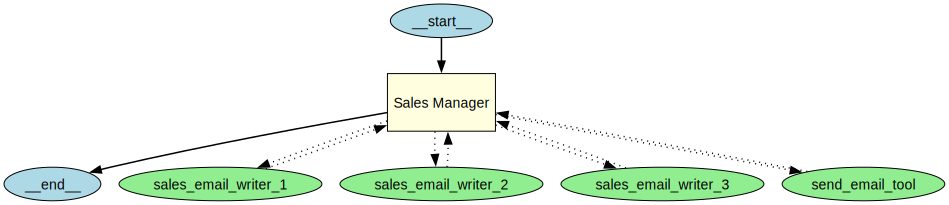

In [21]:
draw_graph(sales_manager)

In [22]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)

OPENAI_API_KEY is not set, skipping trace export


OPENAI_API_KEY is not set, skipping trace export


## Remember to check the trace

https://platform.openai.com/traces

And then check your email!! Also look in your Junk / Spam folder - after all, this is basically a spam message..


<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Unreliable results?</h2>
            <span style="color:#ff7800;">This is par for the course with Agentic AI, and particularly with Orchestrating by LLM.
            To resolve it, you'll need to experiment and iterate with the prompts. Particularly with smaller models, more experiments
            may be needed to get reliable outcomes.
            </span>
        </td>
    </tr>
</table>

## Part 3: Orchestrating by LLMs

### 3a: via Handoffs

I am not a fan of handoffs. They seem very unreliable. They're not used consistently by other frameworks.

Behind the scenes, OpenAI Agents SDK has implemented these with Tools anyway.

### Handoffs represent a way an agent can delegate to an agent, passing control to it

Handoffs and Agents-as-tools are similar:

In both cases, an Agent can collaborate with another Agent

With tools, control passes back

A -> B -> A

With handoffs, control passes across

A -> B

In [ ]:

instructions = """
You are a Sales Manager at ComplAI. You get your sales team to draft emails, then send them all to a sales picker.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Handoff to the sales sender to choose and send the best email.
"""

tools = [tool1, tool2, tool3]
handoffs = [sales_sender]

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, handoffs=handoffs, model=gemini_model)


In [ ]:
draw_graph(sales_manager)

In [ ]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)

### Remember to check the trace

https://platform.openai.com/traces

And then check your email!!

Note that handoffs can be unrealiable and a little bit frustrating. I needed to force the tool use otherwise this didn't work. If you don't get reliable behavior, try iterating on the prompts - or use a larger model. And enjoy the process; this is what Agentic AI is all about!

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">Try extending with some more orchestration - perhaps another iteration of the email to refine it. 
            Use Orchestrating via Code and Orchestrating via LLMs.  
            HARD CHALLENGE: switch to using a professional email provider like SendGrid or Resend. Then handle the user replying. 
            Then have the SDR respond to keep the conversation going!
            </span>
        </td>
    </tr>
</table>

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/business.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#00bfff;">Commercial implications</h2>
            <span style="color:#00bfff;">This is immediately applicable to Sales Automation; but more generally this could be applied to  end-to-end automation of any business process through conversations and tools. Think of ways you could apply an Agent solution
            like this in your day job.
            </span>
        </td>
    </tr>
</table>